# 03 · Logistic Regression and the Confusion Matrix, Explained Visually

Companion notebook for the [lesson](https://github.com/younespuri/visual-machine-learning-for-beginners/blob/main/lessons/03-logistic-regression/README.md). Run the cells from top to bottom with **Shift + Enter**.

### Step 1 · Pass or fail: fit the model

In [1]:
import numpy as np
from sklearn.linear_model import LogisticRegression

# Hours each of 20 students studied, and whether they passed (1) or failed (0)
hours = np.array([0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.25, 2.5, 2.75,
                  3.0, 3.25, 3.5, 4.0, 4.25, 4.5, 4.75, 5.0, 5.5, 6.0])
passed = np.array([0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
                   1, 0, 1, 1, 1, 1, 1, 1, 1, 1])

X = hours.reshape(-1, 1)   # scikit-learn wants a 2-D table: (n_samples, n_features)
y = passed

model = LogisticRegression()
model.fit(X, y)

print("w (coef_):", model.coef_)
print("b (intercept_):", model.intercept_)
# w (coef_): [[1.33189817]]
# b (intercept_): [-3.53787376]

w (coef_): [[1.33189817]]
b (intercept_): [-3.53787376]


- The target `y` holds only 0s and 1s (fail or pass), not a continuous number like a price. That's what makes this a classification problem.
- `fit` finds the w and b with the lowest log loss. The model learned the score **z = 1.33 × hours − 3.54**: each extra hour of study adds 1.33 to the score.
- `coef_` comes back as a 2-D array with one weight per feature. With a single feature, that's just one number.

### Step 2 · Probabilities first, decisions second

In [2]:
new_hours = np.array([[1.0], [3.0], [5.0]])

proba = model.predict_proba(new_hours)   # one column per class: [P(fail), P(pass)]
labels = model.predict(new_hours)        # the final 0/1 answer

print(proba.round(2))
for h, p, label in zip(new_hours.ravel(), proba[:, 1], labels):
    print(f"{h} hours -> P(pass) = {p:.2f} -> predicted class {label}")
# [[0.9  0.1 ]
#  [0.39 0.61]
#  [0.04 0.96]]
# 1.0 hours -> P(pass) = 0.10 -> predicted class 0
# 3.0 hours -> P(pass) = 0.61 -> predicted class 1
# 5.0 hours -> P(pass) = 0.96 -> predicted class 1

[[0.9  0.1 ]
 [0.39 0.61]
 [0.04 0.96]]
1.0 hours -> P(pass) = 0.10 -> predicted class 0
3.0 hours -> P(pass) = 0.61 -> predicted class 1
5.0 hours -> P(pass) = 0.96 -> predicted class 1


- `predict_proba` returns one column per class, and each row adds up to 1. Column 1, `proba[:, 1]`, is the probability of the positive class: passing.
- `predict` applies the 0.5 threshold for you: 0.10 becomes a fail, while 0.61 and 0.96 become a pass.
- 0.61 and 0.96 are both a "pass", but the model is much surer about the second one. `predict` throws that information away; `predict_proba` keeps it.

### Step 3 · Open the box: score, sigmoid, threshold

In [3]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

w, b = model.coef_[0, 0], model.intercept_[0]

score = w * new_hours.ravel() + b     # 1. a straight-line score, as in lesson 02
prob = sigmoid(score)                 # 2. squash it into a probability
decision = (prob >= 0.5).astype(int)  # 3. apply the threshold

print("scores:       ", score.round(2))
print("probabilities:", prob.round(2))
print("decisions:    ", decision)
print("with a 0.7 threshold:", (prob >= 0.7).astype(int))
print("decision boundary: hours =", round(-b / w, 2))
# scores:        [-2.21  0.46  3.12]
# probabilities: [0.1  0.61 0.96]
# decisions:     [0 1 1]
# with a 0.7 threshold: [0 0 1]
# decision boundary: hours = 2.66

scores:        [-2.21  0.46  3.12]
probabilities: [0.1  0.61 0.96]
decisions:     [0 1 1]
with a 0.7 threshold: [0 0 1]
decision boundary: hours = 2.66


- Three short lines reproduce `predict_proba` and `predict` exactly. Logistic regression really is *straight-line score → sigmoid → threshold*.
- With a stricter threshold of 0.7, the 3-hour student (61%) is now predicted to fail. Same probabilities, different decisions.
- The score is 0 (a probability of exactly 0.5) at hours = −b / w ≈ 2.66. That point is the decision boundary for one feature.

### Step 4 · Log loss: grading the probabilities

In [4]:
from sklearn.metrics import log_loss

# A student who really passed (y = 1), and three possible predictions
for p in [0.95, 0.5, 0.05]:
    print(f"P(pass) = {p:.2f}  ->  loss = {-np.log(p):.2f}")

print("our model:        ", round(log_loss(y, model.predict_proba(X)[:, 1]), 3))
print("always guess 0.55:", round(log_loss(y, np.full(len(y), 0.55)), 3))
# P(pass) = 0.95  ->  loss = 0.05
# P(pass) = 0.50  ->  loss = 0.69
# P(pass) = 0.05  ->  loss = 3.00
# our model:         0.325
# always guess 0.55: 0.688

P(pass) = 0.95  ->  loss = 0.05
P(pass) = 0.50  ->  loss = 0.69
P(pass) = 0.05  ->  loss = 3.00
our model:         0.325
always guess 0.55: 0.688


- For one example, log loss is minus the log of the probability given to the true answer. Being 95% sure and right costs 0.05; being 95% sure and wrong costs 3.00, sixty times more.
- `log_loss` averages that over every student. It takes probabilities (from `predict_proba`), not 0/1 labels.
- A lazy guess that ignores study time and always says 0.55 (the share of students who passed: 11 of 20) scores 0.688. Our model's 0.325 is far better. Lower is better, and 0 would be perfect.

### Step 5 · A real problem: finding malignant tumors

In [5]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

data = load_breast_cancer()
X_all = data.data           # 569 tumors, 30 measurements each
y_all = 1 - data.target     # flip the labels so that 1 = malignant, the case we must catch

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.25, stratify=y_all, random_state=42)

cancer_model = make_pipeline(StandardScaler(), LogisticRegression())
cancer_model.fit(X_train, y_train)
y_pred = cancer_model.predict(X_test)

print("train:", X_train.shape, "| test:", X_test.shape)
print("malignant tumors in the test set:", y_test.sum())
# train: (426, 30) | test: (143, 30)
# malignant tumors in the test set: 53

train: (426, 30) | test: (143, 30)
malignant tumors in the test set: 53


- `load_breast_cancer` is a real medical dataset that ships with scikit-learn: 30 measurements of cell nuclei (size, texture, smoothness...) computed from microscope images of 569 breast tumor samples. Its labels say 0 = malignant and 1 = benign, so we flip them. The **positive** class should be the thing you're hunting for.
- `train_test_split` hides 25% of the tumors in a **test set**. The model never sees them during training, so they give an honest grade. `stratify=y_all` keeps the same share of malignant tumors in both parts, and `random_state` fixes the shuffle so you get the same numbers as here.
- `StandardScaler` puts every feature on a similar scale so training runs smoothly, and `make_pipeline` glues it to the model so that `fit` and `predict` run both steps. More on scaling in lesson 05.

### Step 6 · The confusion matrix

In [6]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

tn, fp, fn, tp = cm.ravel()
print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")
# [[89  1]
#  [ 4 49]]
# TN=89  FP=1  FN=4  TP=49

[[89  1]
 [ 4 49]]
TN=89  FP=1  FN=4  TP=49


- Rows are the truth and columns are the prediction, class 0 first: the same layout as the diagram above.
- `cm.ravel()` unrolls the table into TN, FP, FN, TP, in that order.
- 138 of the 143 tumors are classified correctly. But the 5 mistakes are not equal: 1 false alarm (a benign tumor flagged, which costs an extra test) and 4 missed cancers (which could cost a life).

### Step 7 · Accuracy, precision, recall and F1

In [7]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report

print(f"accuracy:  {accuracy_score(y_test, y_pred):.3f}")
print(f"precision: {precision_score(y_test, y_pred):.3f}")
print(f"recall:    {recall_score(y_test, y_pred):.3f}")
print(f"F1:        {f1_score(y_test, y_pred):.3f}")
print()
print(classification_report(y_test, y_pred, target_names=["benign", "malignant"]))
# accuracy:  0.965
# precision: 0.980
# recall:    0.925
# F1:        0.951
#
#               precision    recall  f1-score   support
#
#       benign       0.96      0.99      0.97        90
#    malignant       0.98      0.92      0.95        53
#
#     accuracy                           0.97       143
#    macro avg       0.97      0.96      0.96       143
# weighted avg       0.97      0.97      0.96       143

accuracy:  0.965
precision: 0.980
recall:    0.925
F1:        0.951

              precision    recall  f1-score   support

      benign       0.96      0.99      0.97        90
   malignant       0.98      0.92      0.95        53

    accuracy                           0.97       143
   macro avg       0.97      0.96      0.96       143
weighted avg       0.97      0.97      0.96       143



- Precision 0.980: when the model says *malignant*, it's right 98% of the time (49 of 50).
- Recall 0.925: it found 49 of the 53 malignant tumors and missed 4. For a cancer screen, that's the number to worry about.
- `classification_report` shows precision, recall and F1 for *each* class, plus the **support**: how many test examples each class has. It's the quickest way to see everything at once.

### Step 8 · Move the threshold

In [8]:
from sklearn.metrics import roc_auc_score

p_malignant = cancer_model.predict_proba(X_test)[:, 1]   # P(malignant) for each test tumor

for t in [0.1, 0.3, 0.5, 0.7, 0.9]:
    pred_t = (p_malignant >= t).astype(int)
    _, false_alarms, missed, _ = confusion_matrix(y_test, pred_t).ravel()
    print(f"threshold {t}:  precision {precision_score(y_test, pred_t):.2f}   "
          f"recall {recall_score(y_test, pred_t):.2f}   "
          f"false alarms {false_alarms}   missed cancers {missed}")

print("ROC-AUC:", round(roc_auc_score(y_test, p_malignant), 3))
# threshold 0.1:  precision 0.90   recall 0.98   false alarms 6   missed cancers 1
# threshold 0.3:  precision 0.98   recall 0.96   false alarms 1   missed cancers 2
# threshold 0.5:  precision 0.98   recall 0.92   false alarms 1   missed cancers 4
# threshold 0.7:  precision 1.00   recall 0.91   false alarms 0   missed cancers 5
# threshold 0.9:  precision 1.00   recall 0.81   false alarms 0   missed cancers 10
# ROC-AUC: 0.996

threshold 0.1:  precision 0.90   recall 0.98   false alarms 6   missed cancers 1
threshold 0.3:  precision 0.98   recall 0.96   false alarms 1   missed cancers 2
threshold 0.5:  precision 0.98   recall 0.92   false alarms 1   missed cancers 4
threshold 0.7:  precision 1.00   recall 0.91   false alarms 0   missed cancers 5
threshold 0.9:  precision 1.00   recall 0.81   false alarms 0   missed cancers 10
ROC-AUC: 0.996


- Lowering the threshold makes the model say *malignant* more easily: recall rises (fewer missed cancers) and precision falls (more false alarms). Raising it does the opposite.
- For cancer screening, a false alarm means an extra test, while a miss can cost a life. So a low threshold, like 0.3 or even 0.1, is the sensible choice here.
- In a real project, pick the threshold on data set aside for that job, not on the test set, or the test grade stops being honest. Lesson 08 shows how.
- A ROC-AUC of 0.996 means that for a random malignant tumor and a random benign one, the model gives the malignant one the higher probability 99.6% of the time.

### Step 9 · The accuracy trap

In [9]:
from sklearn.dummy import DummyClassifier

# A rare disease: only 2 of 200 people are sick (1%)
y_rare = np.zeros(200, dtype=int)
y_rare[:2] = 1
X_rare = np.zeros((200, 1))    # this "model" ignores the features anyway

lazy = DummyClassifier(strategy="most_frequent")   # always answers the most common class
lazy.fit(X_rare, y_rare)
y_lazy = lazy.predict(X_rare)

print("accuracy:", accuracy_score(y_rare, y_lazy))
print("recall:  ", recall_score(y_rare, y_lazy))
print(confusion_matrix(y_rare, y_lazy))
# accuracy: 0.99
# recall:   0.0
# [[198   0]
#  [  2   0]]

accuracy: 0.99
recall:   0.0
[[198   0]
 [  2   0]]


- `DummyClassifier` learns nothing: it always answers "healthy", the most common class. That makes it a useful **baseline**, a floor that any real model has to beat.
- 99% accuracy, yet a recall of 0. The confusion matrix shows why: TP = 0, and both sick people land in FN.
- On imbalanced data, never trust accuracy alone. Check precision and recall for the rare class, and compare against a baseline like this one.

### See it

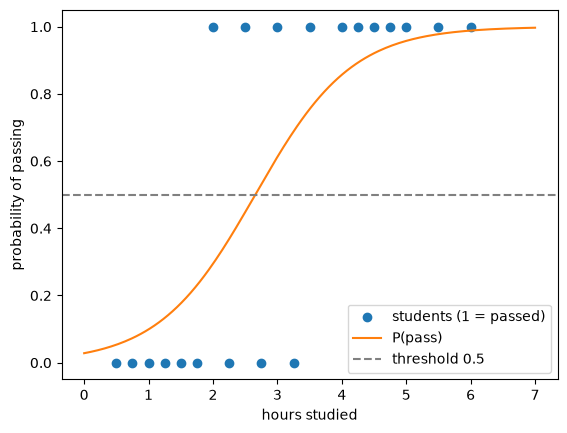

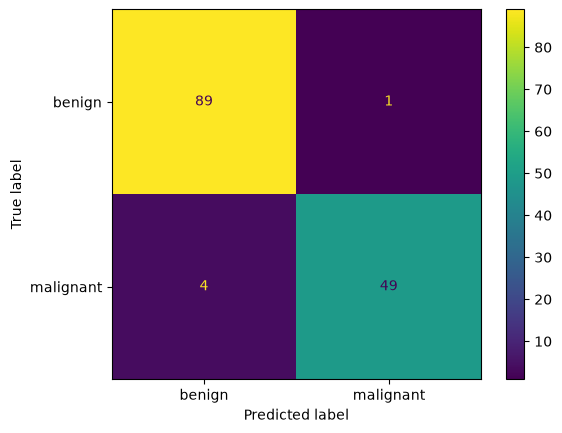

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# The S-curve the student model learned
xs = np.linspace(0, 7, 200).reshape(-1, 1)
plt.scatter(hours, passed, label="students (1 = passed)")
plt.plot(xs, model.predict_proba(xs)[:, 1], color="tab:orange", label="P(pass)")
plt.axhline(0.5, color="gray", linestyle="--", label="threshold 0.5")
plt.xlabel("hours studied")
plt.ylabel("probability of passing")
plt.legend()
plt.show()

# The cancer model's confusion matrix from Step 6, drawn as a picture
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["benign", "malignant"])
plt.show()